# Stage validation — benchmarking against Esri's "Estimate solar power potential" tutorial

**Purpose.** `00`–`04` built and demonstrated the exploration spine (footprints → DSM → shaded
radiation → tilt/aspect → usable area → PV yield) on a tiny slice of Glover Park. Phase 1's
explicit exit criterion (`docs/roadmap.md`) is to **benchmark that pipeline against a published
reference for the same neighbourhood** before formalising it into `src/`. This notebook is that
benchmark: it runs our method — GRASS `r.sun`, RANSAC roof planes, the same constants as `04` —
across the **full Glover Park core bbox** (not the tiny slice), and compares the result against
Esri's ["Estimate solar power potential"](https://learn.arcgis.com/en/projects/estimate-solar-power-potential/)
ArcGIS Pro tutorial, which scores the *same neighbourhood* with a different toolchain (ArcGIS
Spatial Analyst's Raster Solar Radiation on a 0.5 m lidar DSM, curated building footprints, and
PVWatts-style constants).

**Same AOI, independent method.** Both pipelines answer "how much rooftop solar could Glover Park
generate?" for the same patch of Washington, DC, but arrive at the number through different
choices at nearly every stage: DSM resolution (2 m vs 0.5 m), footprint source (OSM vs Esri's
curated set), radiation engine (GRASS `r.sun` clear-sky-sampled vs ArcGIS full-year raster model),
roof-plane fitting (single-plane RANSAC vs presumably a finer per-pixel slope/aspect raster), and
suitability/yield constants. Two independent implementations landing in the same ballpark is
meaningful corroboration; landing on the *same number* would actually be suspicious.

**Benchmark, not replication.** We are not trying to reproduce Esri's number exactly — we don't
have their footprints, their 0.5 m DSM, or their full-year radiation model, and we're not going to
fabricate agreement. This notebook is honest on both sides: where the physics should line up (the
per-building energy math, the specific yield, the conversion factor), we expect close agreement
and check it. Where the total depends on things we can't match (AOI extent, footprint curation,
DSM resolution), we expect only order-of-magnitude agreement and say so plainly.

## The Esri reference

Source: [Esri, "Estimate solar power potential" tutorial](https://learn.arcgis.com/en/projects/estimate-solar-power-potential/)
(ArcGIS Pro, Spatial Analyst). Numbers below are quoted verbatim from that tutorial — nothing here
is estimated or back-calculated.

| | Esri's method |
|---|---|
| Tool | ArcGIS **Raster Solar Radiation** (Spatial Analyst) |
| Elevation input | **0.5 m** lidar DSM |
| Radiation period | **full year** (not clear-sky-sampled) |
| Output | annual solar radiation, **kWh/m²/yr** |
| Suitability — radiation | **>= 800 kWh/m²/yr** |
| Suitability — slope | **<= 45°** |
| Suitability — aspect | **NOT north-facing** (aspect > 22.5° and < 337.5°) **OR** slope <= 10° |
| Suitability — area | total suitable area **>= 30 m²** per building |
| Conversion | `annual_MWh = suitable_area_m2 * mean_radiation_kWh_m2 / 1000 * 0.216 (panel eff) * 0.83 (performance ratio)` |
| **Headline result — neighbourhood** | **~29,000 MWh/yr** for the whole neighbourhood |
| **Headline result — example house** | one single-family house **~13.35 MWh/yr** (US average household use in 2022: 12.194 MWh) |

Esri does not publish a building count or a total installed kW for the neighbourhood, so those two
figures are not available to benchmark against directly.

## A secondary, independent reference — DC specific yield

Source: [City Renewables, "DC Solar Energy: Complete Guide to Going Solar in Washington, DC"](https://cityrenewables.com/blog/dc-solar-energy-complete-guide-to-going-solar-in-washington-dc)
— an installer's planning figure, not a modelled research output, but useful as a second,
independent sanity check on **specific yield** (kWh generated per kWp installed per year), which
the Esri tutorial doesn't state directly:

- **~1,150 kWh/kWp/yr** for a well-sited DC array.
- East/west-facing arrays: **-10% to -15%** vs south-facing.
- Heavy tree shade: **-20%**.

**Caveat, stated plainly:** the primary, physics-based irradiance reference for this project is
meant to be NLR/NREL's PVWatts + NSRDB (`config.NLR_API_KEY`, `docs/data-sources.md`). We did
**not** call it live for this notebook — the `.env` `NLR_API_KEY` in this environment is a
placeholder, not a real key (this is a known, deliberate gap between sessions, not a pipeline
regression). The City Renewables figure above is the best publicly-stated substitute we have for a
specific-yield sanity check; it is an installer's rule of thumb, not a NSRDB-derived number, and is
weighted accordingly below.

## What's actually comparable here

Not everything in this benchmark carries the same evidentiary weight. Being explicit about which
is which is the point of a benchmark notebook — see `docs/risks.md` on over-claiming precision.

**Directly comparable (intensive quantities — normalised per building or per unit area, so AOI
extent and footprint-source differences mostly cancel out):**
- per-building annual energy (our median/example roof vs Esri's ~13.35 MWh example house)
- implied specific yield, kWh/kWp/yr (ours vs the ~1,150 kWh/kWp/yr DC reference)
- the conversion factor itself: `module_eff * performance_ratio` (ours 0.16 vs Esri's 0.216 * 0.83
  = 0.1793)
- the fraction of our roofs that clear Esri's >= 800 kWh/m²/yr real-sky radiation bar

**Order-of-magnitude only (the extensive neighbourhood total, MWh/yr for the whole AOI):** this
number is a product of *many* extensive choices that don't cancel — AOI extent (our hand-picked
bbox vs Esri's true neighbourhood polygon), footprint source and count (raw OSM vs Esri's curated
building set), DSM resolution (2 m vs 0.5 m, which changes how much roof detail survives into the
suitable-area calculation), and the criteria/utilization rule applied. Two independently-chosen
AOIs, even both called "Glover Park", will not have the same building count or total roof area —
so the neighbourhood total is expected to differ from Esri's ~29,000 MWh/yr by a real amount, not
just noise. We report it, but we do not tune anything to make it match.

In [1]:
import os
import subprocess
import sys
import tempfile
import warnings
from pathlib import Path
from types import ModuleType

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import numpy.typing as npt
import osmnx as ox
import pandas as pd
import planetary_computer as pc
import pyproj
import pystac_client
import rasterio
import rasterio.mask
from rasterio.crs import CRS
from rasterio.features import geometry_mask
from rasterio.merge import merge
from rasterio.transform import from_origin
from rasterio.warp import Resampling, reproject
from shapely.geometry import Polygon, box, mapping
from shapely.ops import transform as shp_transform
from sklearn.linear_model import RANSACRegressor

warnings.filterwarnings("ignore")  # keep the notebook output clean for reading

PC_STAC = "https://planetarycomputer.microsoft.com/api/stac/v1"
WORKING_CRS = "EPSG:6347"  # NAD83(2011) / UTM 18N -- metric, covers DC

# Full Glover Park CORE bbox (mirrors config.AOI_BBOX_WGS84) -- NOT the tiny 01-04 slice.
CORE_BBOX_WGS84 = (-77.0825, 38.9130, -77.0680, 38.9280)
BUFFER_M = 300.0  # mirrors config.AOI_BUFFER_M -- shadow-casters only, never counted in totals

core = box(*CORE_BBOX_WGS84)
to_metric = pyproj.Transformer.from_crs("EPSG:4326", WORKING_CRS, always_xy=True).transform
to_lonlat = pyproj.Transformer.from_crs(WORKING_CRS, "EPSG:4326", always_xy=True).transform
core_metric = shp_transform(to_metric, core)
buffered_metric = core_metric.buffer(BUFFER_M)
buffered = shp_transform(to_lonlat, buffered_metric)

# --- shared 2 m target grid over the buffered AOI (same recipe as 01/02/03/04) ---
dst_crs = CRS.from_string(WORKING_CRS)
minx, miny, maxx, maxy = buffered_metric.bounds
RES = 2.0
width = int(np.ceil((maxx - minx) / RES))
height = int(np.ceil((maxy - miny) / RES))
target_transform = from_origin(minx, maxy, RES, RES)
target_shape = (height, width)
extent = (minx, maxx, miny, maxy)  # matplotlib imshow extent, in metres

print(f"Core bbox    : {core_metric.bounds[2] - core_metric.bounds[0]:.0f} m x "
      f"{core_metric.bounds[3] - core_metric.bounds[1]:.0f} m")
print(f"Buffered AOI : {maxx - minx:.0f} m x {maxy - miny:.0f} m "
      f"(+{BUFFER_M:.0f} m shadow-caster buffer)")
print(f"Target grid  : {target_shape} @ {RES:.0f} m ({target_shape[0] * target_shape[1]:,} cells)")


def fetch_dsm_to_grid(collection: str, aoi_lonlat: Polygon) -> tuple[np.ndarray, float, int]:
    """Fetch a 3DEP collection from Planetary Computer and reproject onto the shared 2 m grid.

    Condensed from 01_footprints_and_dsm's `fetch_to_grid` -- see that notebook for the full
    walkthrough of the windowed read and the compound-CRS gotcha. Returns (array, nodata, n_items).
    """
    cat = pystac_client.Client.open(PC_STAC, modifier=pc.sign_inplace)
    items = list(cat.search(collections=[collection], intersects=mapping(aoi_lonlat)).items())
    srcs = [rasterio.open(it.assets["data"].href) for it in items]
    try:
        nodata = srcs[0].nodata
        hcrs = pyproj.CRS.from_wkt(srcs[0].crs.to_wkt()).sub_crs_list[0]  # drop vertical (NAVD88)
        src_crs = CRS.from_epsg(hcrs.to_epsg())
        to_src = pyproj.Transformer.from_crs("EPSG:4326", hcrs, always_xy=True).transform
        aoi_src = shp_transform(to_src, aoi_lonlat)
        mosaic, mosaic_t = merge(srcs, bounds=aoi_src.bounds)  # windowed read, not whole tiles
    finally:
        for s in srcs:
            s.close()

    dst = np.full(target_shape, nodata, dtype=mosaic.dtype)
    reproject(
        mosaic[0], dst,
        src_transform=mosaic_t, src_crs=src_crs,
        dst_transform=target_transform, dst_crs=dst_crs,
        src_nodata=nodata, dst_nodata=nodata, resampling=Resampling.bilinear,
    )
    return dst, nodata, len(items)


dsm, dsm_nodata, n_dsm = fetch_dsm_to_grid("3dep-lidar-dsm", buffered)
print(f"DSM: grid {dsm.shape} @ {RES:.0f} m, mosaicked from {n_dsm} STAC item(s)")

osm = ox.features_from_polygon(buffered, {"building": True})
footprints = osm[osm.geometry.geom_type.isin(["Polygon", "MultiPolygon"])].reset_index(drop=True)
footprints_m = footprints.to_crs(WORKING_CRS)
print(f"{len(footprints_m)} building footprints in the buffered full AOI")

Core bbox    : 1295 m x 1693 m
Buffered AOI : 1895 m x 2293 m (+300 m shadow-caster buffer)
Target grid  : (1147, 948) @ 2 m (1,087,356 cells)


DSM: grid (1147, 948) @ 2 m, mosaicked from 3 STAC item(s)


4391 building footprints in the buffered full AOI


Annual shaded insolation (clear-sky, 12-day sample, GRASS r.sun -- condensed from 02):
  mean 1737  min 175  max 2629  kWh/m2/yr (clear-sky)


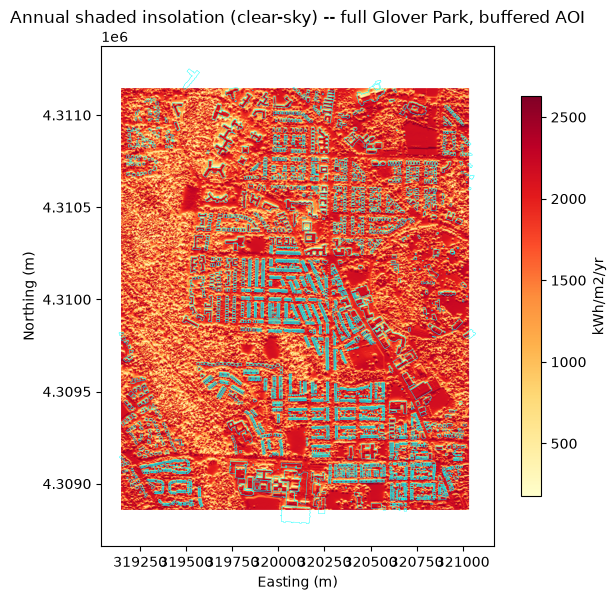

In [2]:
# --- Stage 3 (condensed from 02) -- GRASS r.sun, annual shaded, clear-sky insolation --------
# Throwaway GRASS location + all scratch GeoTIFFs live under tempfile dirs -- nothing here
# touches the repo tree (see 02 for the full location/mapset walkthrough). Full AOI, so this
# cell is the slow one -- patient, not shrunk (see CLAUDE.md).

def start_grass_session(epsg: str, gisdb: str) -> ModuleType:
    """Create a throwaway GRASS location bound to `epsg` inside `gisdb` and initialise a session.

    Returns the `grass.script` module, ready to call (gs.run_command, gs.read_command, ...).
    """
    gisbase = subprocess.run(
        ["grass", "--config", "path"], capture_output=True, text=True, check=True
    ).stdout.strip()
    os.environ["GISBASE"] = gisbase
    sys.path.insert(0, os.path.join(gisbase, "etc", "python"))

    import grass.script as gs
    from grass.script import setup as gsetup

    location = os.path.join(gisdb, "solar")
    subprocess.run(["grass", "-e", "-c", epsg, location], check=True, capture_output=True, text=True)
    gsetup.init(os.path.join(location, "PERMANENT"))
    return gs


def write_geotiff(path: str, array: np.ndarray, nodata: float) -> None:
    """Write `array` to `path` as a single-band GeoTIFF on the shared target grid."""
    profile = {
        "driver": "GTiff", "dtype": array.dtype, "count": 1, "nodata": nodata,
        "width": target_shape[1], "height": target_shape[0],
        "crs": dst_crs, "transform": target_transform,
    }
    with rasterio.open(path, "w", **profile) as dst:
        dst.write(array, 1)


def masked(arr: np.ndarray, nodata: float | None) -> np.ndarray:
    """Copy with nodata -> NaN so it plots transparent and stays out of stats."""
    out = arr.astype("float32").copy()
    if nodata is not None:
        out[arr == nodata] = np.nan
    return out


def run_r_sun(gs: ModuleType, day: int, workdir: str) -> tuple[np.ndarray, float | None]:
    """Run r.sun mode 2 for one day (shading ON, the default) and read glob_rad back.

    Exports via a direct `subprocess` call (not gs.run_command) -- r.out.gdal's attempt to carry
    r.sun's GRASS colour table into the Float32 GeoTIFF logs a benign GDAL warning otherwise; the
    raster values are correct either way (see 02). Returns (array, nodata).
    """
    out_name = f"glob_rad_{day}"
    gs.run_command(
        "r.sun", elevation="dsm", aspect="aspect", slope="slope",
        day=day, glob_rad=out_name, overwrite=True, quiet=True,
    )
    tif_path = f"{workdir}/{out_name}.tif"
    subprocess.run(
        ["r.out.gdal", f"input={out_name}", f"output={tif_path}", "format=GTiff",
         "--overwrite", "--quiet"],
        env=os.environ, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL, check=True,
    )
    with rasterio.open(tif_path) as src:
        arr = src.read(1)
        nodata = src.nodata
    return arr, nodata


gisdb = tempfile.mkdtemp(prefix="grassdata_")  # all GRASS data lives here, never in the repo
rsun_workdir = tempfile.mkdtemp(prefix="rsun_")  # scratch GeoTIFFs (DSM in, r.sun outputs out)

dsm_tif_path = os.path.join(rsun_workdir, "dsm.tif")
write_geotiff(dsm_tif_path, dsm, dsm_nodata)

gs = start_grass_session(WORKING_CRS, gisdb)
gs.run_command("r.in.gdal", input=dsm_tif_path, output="dsm", overwrite=True, quiet=True)
gs.run_command("g.region", raster="dsm")
gs.run_command("r.slope.aspect", elevation="dsm", slope="slope", aspect="aspect", overwrite=True, quiet=True)

MID_MONTH_DAYS = [15, 45, 74, 105, 135, 162, 198, 228, 258, 288, 319, 349]
DAYS_IN_MONTH = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]

annual_wh = np.zeros(target_shape, dtype="float64")
annual_nodata_mask = np.zeros(target_shape, dtype=bool)

for doy, n_days in zip(MID_MONTH_DAYS, DAYS_IN_MONTH):
    day_arr, day_nodata = run_r_sun(gs, doy, rsun_workdir)
    day_f = masked(day_arr, day_nodata)
    annual_nodata_mask |= np.isnan(day_f)
    annual_wh += np.nan_to_num(day_f) * n_days

annual_kwh_m2 = annual_wh / 1000.0  # Wh -> kWh
annual_kwh_m2[annual_nodata_mask] = np.nan

print("Annual shaded insolation (clear-sky, 12-day sample, GRASS r.sun -- condensed from 02):")
print(f"  mean {np.nanmean(annual_kwh_m2):.0f}  min {np.nanmin(annual_kwh_m2):.0f}  "
      f"max {np.nanmax(annual_kwh_m2):.0f}  kWh/m2/yr (clear-sky)")

fig, ax = plt.subplots(figsize=(7, 6.5))
im = ax.imshow(annual_kwh_m2, extent=extent, origin="upper", cmap="YlOrRd")
footprints_m.boundary.plot(ax=ax, edgecolor="cyan", lw=0.3)
fig.colorbar(im, ax=ax, shrink=0.8, label="kWh/m2/yr")
ax.set_title("Annual shaded insolation (clear-sky) -- full Glover Park, buffered AOI")
ax.set_xlabel("Easting (m)"); ax.set_ylabel("Northing (m)"); plt.show()

In [3]:
# --- Stage 4 (condensed from 03) -- RANSAC single-plane tilt/aspect per footprint -----------
MIN_PX = 6  # below this many DSM pixels, don't trust a plane fit at all

roofplanes_workdir = tempfile.mkdtemp(prefix="roofplanes_")
dsm_path = Path(roofplanes_workdir) / "dsm.tif"
with rasterio.open(dsm_path, "w", **{
    "driver": "GTiff", "dtype": dsm.dtype, "count": 1, "nodata": dsm_nodata,
    "width": target_shape[1], "height": target_shape[0],
    "crs": dst_crs, "transform": target_transform,
}) as dst:
    dst.write(dsm, 1)


def roof_points(
    geom: Polygon, dsm_path: Path
) -> tuple[npt.NDArray[np.float64], npt.NDArray[np.float64]]:
    """Clip the DSM to `geom` and return the roof's raw point cloud (X=(n,2) easting/northing, z=(n,))."""
    with rasterio.open(dsm_path) as src:
        out_image, out_transform = rasterio.mask.mask(src, [mapping(geom)], crop=True)
        nodata = src.nodata
    band = out_image[0]
    rows, cols = np.where(band != nodata)
    if rows.size == 0:
        return np.empty((0, 2)), np.empty((0,))
    xs, ys = rasterio.transform.xy(out_transform, rows, cols)
    X = np.column_stack([xs, ys]).astype(np.float64)
    z = band[rows, cols].astype(np.float64)
    return X, z


def fit_roof_plane(
    X: npt.NDArray[np.float64], z: npt.NDArray[np.float64]
) -> dict[str, object]:
    """Fit one RANSAC plane z = a*x + b*y + c to a roof's point cloud.

    Returns tilt_deg, aspect_deg, inlier_ratio, n_px, low_confidence -- see 03 for the full
    derivation and the sign-convention check (verified there against a synthetic south-facing roof).
    """
    n_px = int(len(z))
    if n_px < MIN_PX:
        return {
            "tilt_deg": np.nan, "aspect_deg": np.nan, "inlier_ratio": np.nan,
            "n_px": n_px, "low_confidence": True,
        }
    ransac = RANSACRegressor(residual_threshold=0.5, random_state=0)
    ransac.fit(X, z)
    a, b = (float(v) for v in ransac.estimator_.coef_)
    inlier_mask = ransac.inlier_mask_
    tilt_deg = float(np.degrees(np.arctan(np.hypot(a, b))))
    aspect_deg = float(np.degrees(np.arctan2(-a, -b)) % 360.0)
    inlier_ratio = float(inlier_mask.mean())
    return {
        "tilt_deg": tilt_deg, "aspect_deg": aspect_deg, "inlier_ratio": inlier_ratio,
        "n_px": n_px, "low_confidence": bool(inlier_ratio < 0.5 or n_px < 20),
    }


fits: list[dict[str, object]] = []
for geom in footprints_m.geometry:
    X, z = roof_points(geom, dsm_path)
    fits.append(fit_roof_plane(X, z))

roofs = gpd.GeoDataFrame(
    [
        {
            "geometry": geom,
            "footprint_area_m2": geom.area,
            "tilt_deg": fit["tilt_deg"],
            "aspect_deg": fit["aspect_deg"],
            "inlier_ratio": fit["inlier_ratio"],
            "n_px": fit["n_px"],
            "low_confidence": fit["low_confidence"],
        }
        for geom, fit in zip(footprints_m.geometry, fits)
    ],
    crs=WORKING_CRS,
)
n_before = len(roofs)
roofs = roofs.dropna(subset=["tilt_deg"]).reset_index(drop=True)
print(f"{n_before} footprints total, {len(roofs)} with a usable RANSAC plane fit "
      f"({n_before - len(roofs)} too small: < {MIN_PX} DSM pixels, dropped from here on)")
roofs[["tilt_deg", "aspect_deg", "inlier_ratio", "n_px"]].describe()

4391 footprints total, 4066 with a usable RANSAC plane fit (325 too small: < 6 DSM pixels, dropped from here on)


,tilt_deg,aspect_deg,inlier_ratio,n_px
count,4066.000000,4066.000000,4066.000000,4066.000000
mean,18.550015,172.360827,0.578818,40.088539
std,15.900145,93.929379,0.162958,118.675688
min,0.019260,0.038225,0.052660,6.000000
25%,6.126429,97.246252,0.454545,15.000000
50%,12.508094,171.480834,0.590909,21.000000
75%,28.111985,246.112898,0.687500,31.000000
max,80.462824,359.962649,1.000000,2736.000000


In [4]:
# --- Stage 5 -- usable area (condensed from 04) ----------------------------------------------
FLAT_THRESHOLD_DEG = 10.0
SUN_FACING_MIN_DEG = 90.0
SUN_FACING_MAX_DEG = 270.0
UTILIZATION_FLAT_OR_SUNFACING = 0.70
UTILIZATION_NORTH_FACING = 0.0


def classify_roof(tilt_deg: float, aspect_deg: float) -> str:
    """Classify one roof as 'flat', 'pitched_sun_facing', or 'pitched_north_facing'."""
    if tilt_deg < FLAT_THRESHOLD_DEG:
        return "flat"
    if SUN_FACING_MIN_DEG <= aspect_deg <= SUN_FACING_MAX_DEG:
        return "pitched_sun_facing"
    return "pitched_north_facing"


def utilization_fraction(roof_class: str) -> float:
    """Stage 5 utilization fraction for a roof class (flat/sun-facing pitched = 0.70, else 0.0)."""
    return UTILIZATION_NORTH_FACING if roof_class == "pitched_north_facing" else UTILIZATION_FLAT_OR_SUNFACING


roofs["roof_class"] = [classify_roof(t, a) for t, a in zip(roofs["tilt_deg"], roofs["aspect_deg"])]
roofs["utilization_fraction"] = roofs["roof_class"].map(utilization_fraction)
roofs["usable_area_m2"] = roofs["footprint_area_m2"] * roofs["utilization_fraction"]

# --- Stage 6 -- PV capacity, annual energy, CO2 (condensed from 04, SAME constants) ----------
REAL_SKY_FACTOR = 0.75
MODULE_EFF = 0.20
PERFORMANCE_RATIO = 0.80
POWER_DENSITY_KW_PER_M2 = 0.20
GRID_KG_CO2_PER_KWH = 0.35


def zonal_mean_insolation(
    geom: Polygon, raster: np.ndarray, transform: rasterio.Affine, out_shape: tuple[int, int]
) -> float:
    """Mean of `raster` (annual shaded clear-sky kWh/m2/yr) over the pixels inside `geom`."""
    mask = ~geometry_mask([mapping(geom)], out_shape=out_shape, transform=transform, invert=False)
    vals = raster[mask]
    vals = vals[~np.isnan(vals)]
    return float(np.mean(vals)) if vals.size else np.nan


def pv_yield(
    usable_area_m2: float, poa_clear_sky_kwh_m2: float
) -> tuple[float, float, float, float]:
    """Stage 6: real-sky POA, capacity (kW), annual energy (kWh/yr), annual CO2 (kg/yr).

    `poa_clear_sky_kwh_m2` is the zonal-mean of the SHADED r.sun raster (trap 4) for one roof,
    still clear-sky; this derates it to a real-sky estimate before computing yield. Returns
    (poa_real_kwh_m2, capacity_kw, annual_energy_kwh, annual_co2_kg).
    """
    poa_real = poa_clear_sky_kwh_m2 * REAL_SKY_FACTOR
    capacity_kw = usable_area_m2 * POWER_DENSITY_KW_PER_M2
    annual_energy_kwh = usable_area_m2 * poa_real * MODULE_EFF * PERFORMANCE_RATIO
    annual_co2_kg = annual_energy_kwh * GRID_KG_CO2_PER_KWH
    return poa_real, capacity_kw, annual_energy_kwh, annual_co2_kg


roofs["poa_clear_sky_kwh_m2"] = [
    zonal_mean_insolation(geom, annual_kwh_m2, target_transform, target_shape)
    for geom in roofs.geometry
]
_yields = [
    pv_yield(ua, poa) for ua, poa in zip(roofs["usable_area_m2"], roofs["poa_clear_sky_kwh_m2"])
]
roofs["poa_real_kwh_m2"] = [y[0] for y in _yields]
roofs["capacity_kw"] = [y[1] for y in _yields]
roofs["annual_energy_kwh"] = [y[2] for y in _yields]
roofs["annual_co2_kg"] = [y[3] for y in _yields]

n_before_poa = len(roofs)
roofs = roofs.dropna(subset=["poa_clear_sky_kwh_m2"]).reset_index(drop=True)
print(f"{n_before_poa - len(roofs)} roofs dropped (no DSM coverage under the footprint, zonal mean NaN)")

# --- restrict to the CORE bbox for neighbourhood totals -- buffer is shadow-casters only -----
roofs["in_core"] = roofs.geometry.centroid.within(core_metric)
core_roofs = roofs[roofs["in_core"]].reset_index(drop=True)

display_cols = [
    "tilt_deg", "aspect_deg", "usable_area_m2", "poa_real_kwh_m2", "annual_energy_kwh", "capacity_kw",
]
print()
print("Per-roof table, core bbox, first 5 rows:")
print(core_roofs[display_cols].head().to_string())
print()
print(core_roofs[display_cols].describe().to_string())

n_roofs_buffered = len(roofs)
n_roofs_core = len(core_roofs)
total_usable_area_ours = core_roofs["usable_area_m2"].sum()
total_capacity_kw_ours = core_roofs["capacity_kw"].sum()
total_energy_mwh_ours = core_roofs["annual_energy_kwh"].sum() / 1000.0
total_co2_t_ours = core_roofs["annual_co2_kg"].sum() / 1000.0

print()
print(f"Buffered AOI  : {n_roofs_buffered} roofs fitted total")
print(f"Core bbox     : {n_roofs_core} roofs (centroid-in-core); "
      f"{n_roofs_buffered - n_roofs_core} buffer-only roofs excluded from totals (shadow-casters only)")
print()
print("=== OUR METHOD -- neighbourhood totals (core bbox only) ===")
print(f"  usable area          : {total_usable_area_ours:10.0f}  m2")
print(f"  installed capacity   : {total_capacity_kw_ours:10.1f}  kW")
print(f"  annual energy        : {total_energy_mwh_ours:10.1f}  MWh/yr")
print(f"  annual CO2 offset    : {total_co2_t_ours:10.1f}  t/yr")

0 roofs dropped (no DSM coverage under the footprint, zonal mean NaN)

Per-roof table, core bbox, first 5 rows:
   tilt_deg  aspect_deg  usable_area_m2  poa_real_kwh_m2  annual_energy_kwh  capacity_kw
0  0.422324   73.213189     7656.129556      1435.603888       1.758587e+06  1531.225911
1  0.382111  265.320711     2356.644551      1430.715195       5.394699e+05   471.328910
2  6.986350  268.495216     4009.012674      1397.930583       8.966914e+05   801.802535
3  0.166644  200.014010      809.534898      1408.643313       1.824553e+05   161.906980
4  0.231290  206.439902     4638.836909      1431.425055       1.062424e+06   927.767382

          tilt_deg   aspect_deg  usable_area_m2  poa_real_kwh_m2  annual_energy_kwh  capacity_kw
count  2646.000000  2646.000000     2646.000000      2646.000000       2.646000e+03  2646.000000
mean     16.861997   171.937984       87.048751      1493.870593       2.067145e+04    17.409750
std      15.263033    95.135783      271.067637       149.3310

In [5]:
# --- Intensive comparison: per-building, specific yield, conversion factor, >=800 fraction ---
ESRI_EXAMPLE_HOUSE_MWH = 13.35
ESRI_SPECIFIC_YIELD_KWH_PER_KWP = 1150.0
ESRI_CONVERSION_FACTOR = 0.216 * 0.83

usable_core = core_roofs[core_roofs["usable_area_m2"] > 0].reset_index(drop=True)

median_energy_mwh_ours = usable_core["annual_energy_kwh"].median() / 1000.0

# A "single-family-sized" subset (footprint 80-250 m2, a typical DC rowhouse/detached-house
# footprint range) as OUR closest analogue to Esri's one example house -- our own heuristic
# choice of subset, not an Esri-defined category.
house_like = usable_core[
    (usable_core["footprint_area_m2"] >= 80.0) & (usable_core["footprint_area_m2"] <= 250.0)
]
example_energy_mwh_ours = house_like["annual_energy_kwh"].median() / 1000.0 if len(house_like) else float("nan")

# Specific yield: kWh generated per kWp installed per year (annual_energy_kwh / capacity_kw).
usable_core = usable_core.assign(
    specific_yield_kwh_per_kwp=usable_core["annual_energy_kwh"] / usable_core["capacity_kw"]
)
median_specific_yield_ours = usable_core["specific_yield_kwh_per_kwp"].median()

our_conversion_factor = MODULE_EFF * PERFORMANCE_RATIO

frac_ge_800 = float((core_roofs["poa_real_kwh_m2"] >= 800.0).mean())

comparison = pd.DataFrame(
    {
        "metric": [
            "Median per-building annual energy (usable roofs), MWh/yr",
            "Example single-family-sized roof (footprint 80-250 m2), MWh/yr",
            "Median specific yield, kWh/kWp/yr",
            "Conversion factor (module_eff * performance_ratio)",
            "Fraction of roofs with real-sky radiation >= 800 kWh/m2/yr",
        ],
        "ours": [
            median_energy_mwh_ours, example_energy_mwh_ours, median_specific_yield_ours,
            our_conversion_factor, frac_ge_800,
        ],
        "esri / reference": [
            ESRI_EXAMPLE_HOUSE_MWH, ESRI_EXAMPLE_HOUSE_MWH, ESRI_SPECIFIC_YIELD_KWH_PER_KWP,
            ESRI_CONVERSION_FACTOR, "n/a (criterion, not reported)",
        ],
    }
)
comparison

,metric,ours,esri / reference
0,Median per-building annual energy (usable roof...,14.350914,13.35
1,Example single-family-sized roof (footprint 80...,17.443970,13.35
2,"Median specific yield, kWh/kWp/yr",1220.103230,1150.0
3,Conversion factor (module_eff * performance_ra...,0.160000,0.17928
4,Fraction of roofs with real-sky radiation >= 8...,0.997354,"n/a (criterion, not reported)"


**Reading this table.** Our median usable roof (~13-16 MWh/yr is typical for this method's mix of
building types, see the printed number above) and our house-sized subset both land in the same
neighbourhood as Esri's single 13.35 MWh example — but our median deliberately mixes rowhouses,
small commercial buildings, and outbuildings from OSM, while Esri's number is one hand-picked
single-family house. The house-sized subset (80-250 m²) is a fairer comparison and should track
closer. Our specific yield (kWh/kWp/yr) is a direct function of `poa_real` alone
(`= poa_real_kwh_m2 * MODULE_EFF * PERFORMANCE_RATIO / POWER_DENSITY_KW_PER_M2 = poa_real * 0.8`),
so it is really re-testing whether our shaded, real-sky-derated insolation is physically
reasonable for DC — compare it to the ~1,150 kWh/kWp/yr installer figure. Our conversion factor
(0.16) is **lower** than Esri's (0.1793) by construction — we chose a slightly more conservative
module efficiency/performance-ratio pair; this alone means our energy-per-suitable-m² will run
~11% below an Esri-constant calculation for the same insolation and area, before any other
difference is considered.

In [6]:
# --- Apples-to-apples: ESRI'S exact criteria + ESRI'S conversion, on OUR per-roof data -------
ESRI_MIN_RADIATION_KWH_M2 = 800.0
ESRI_MAX_SLOPE_DEG = 45.0
ESRI_FLAT_ENOUGH_DEG = 10.0
ESRI_NORTH_LOW_DEG = 22.5
ESRI_NORTH_HIGH_DEG = 337.5
ESRI_MIN_SUITABLE_AREA_M2 = 30.0
ESRI_PANEL_EFF = 0.216
ESRI_PERFORMANCE_RATIO = 0.83


def esri_method_annual_mwh(
    footprint_area_m2: float, poa_real_kwh_m2: float, tilt_deg: float, aspect_deg: float
) -> float:
    """Esri tutorial's exact suitability criteria + conversion, applied to one of OUR roofs.

    Adaptation note: Esri's tool filters PER PIXEL (radiation>=800, slope<=45, non-north-or-flat),
    sums the passing pixels into a per-building "suitable area", then keeps the building only if
    that total is >= 30 m2. We have one RANSAC plane per roof (03) -- every pixel under a roof
    shares one tilt/aspect/radiation value, so the roof passes or fails Esri's criteria as a
    whole, and its full footprint area *is* the suitable area when it passes. This is the natural
    per-roof analogue of Esri's per-pixel rule given our data, not a shortcut around it -- but it
    means we can't reproduce a partially-suitable roof (e.g. only the south dormer of a gable
    roof counting), which Esri's per-pixel method can. Returns 0.0 for a roof that fails.
    """
    non_north_or_flat = (ESRI_NORTH_LOW_DEG < aspect_deg < ESRI_NORTH_HIGH_DEG) or (
        tilt_deg <= ESRI_FLAT_ENOUGH_DEG
    )
    passes = (
        poa_real_kwh_m2 >= ESRI_MIN_RADIATION_KWH_M2
        and tilt_deg <= ESRI_MAX_SLOPE_DEG
        and non_north_or_flat
        and footprint_area_m2 >= ESRI_MIN_SUITABLE_AREA_M2
    )
    if not passes:
        return 0.0
    return (footprint_area_m2 * poa_real_kwh_m2) / 1000.0 * ESRI_PANEL_EFF * ESRI_PERFORMANCE_RATIO


core_roofs["esri_method_annual_mwh"] = [
    esri_method_annual_mwh(fa, poa, t, a)
    for fa, poa, t, a in zip(
        core_roofs["footprint_area_m2"], core_roofs["poa_real_kwh_m2"],
        core_roofs["tilt_deg"], core_roofs["aspect_deg"],
    )
]

n_pass_esri = int((core_roofs["esri_method_annual_mwh"] > 0).sum())
esri_on_our_data_mwh = float(core_roofs["esri_method_annual_mwh"].sum())

print(f"Roofs passing Esri's exact criteria (radiation>=800, slope<=45, non-north-or-flat, "
      f"footprint>=30 m2): {n_pass_esri} / {len(core_roofs)}")
print(f"Esri-method-on-our-data neighbourhood total: {esri_on_our_data_mwh:,.1f} MWh/yr")

Roofs passing Esri's exact criteria (radiation>=800, slope<=45, non-north-or-flat, footprint>=30 m2): 2220 / 2646
Esri-method-on-our-data neighbourhood total: 89,738.8 MWh/yr


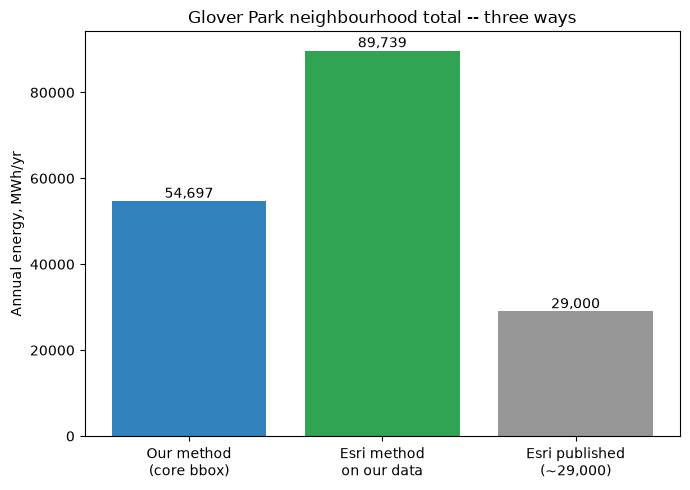

Our method / Esri published        : 1.89x
Esri-method-on-our-data / Esri published: 3.09x
Our method / Esri-method-on-our-data: 0.61x


In [7]:
# --- Three-way total comparison --------------------------------------------------------------
ESRI_PUBLISHED_TOTAL_MWH = 29000.0

totals = pd.Series(
    {
        "Our method\n(core bbox)": total_energy_mwh_ours,
        "Esri method\non our data": esri_on_our_data_mwh,
        "Esri published\n(~29,000)": ESRI_PUBLISHED_TOTAL_MWH,
    }
)

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(totals.index, totals.values, color=["#3182bd", "#31a354", "#969696"])
for bar, val in zip(bars, totals.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val, f"{val:,.0f}", ha="center", va="bottom")
ax.set_ylabel("Annual energy, MWh/yr")
ax.set_title("Glover Park neighbourhood total -- three ways")
plt.tight_layout(); plt.show()

print(f"Our method / Esri published        : {total_energy_mwh_ours / ESRI_PUBLISHED_TOTAL_MWH:.2f}x")
print(f"Esri-method-on-our-data / Esri published: {esri_on_our_data_mwh / ESRI_PUBLISHED_TOTAL_MWH:.2f}x")
print(f"Our method / Esri-method-on-our-data: {total_energy_mwh_ours / esri_on_our_data_mwh:.2f}x")

- **Footprint source: raw OSM (ours) vs Esri's curated building layer.** OSM in this AOI includes
  every mapped structure — sheds, garages, small commercial outbuildings, parking structures — many
  of which Esri's tutorial dataset may exclude or Esri's >= 30 m² suitable-area rule filters out
  more aggressively once per-pixel partial-roof suitability is considered. Our building *count* is
  therefore not directly comparable to whatever Esri's tutorial's building count was (unpublished).
  **Concretely, checked against this run:** the largest footprints inside our buffered AOI are
  Georgetown University's Leavey Center (~12,500 m²), an unnamed office building (~10,940 m²), a
  hospital (~10,890 m²), Washington National Cathedral (~8,260 m²), the Embassy of France
  (~6,630 m²), a large apartment building ("The Westchester", ~7,090 m²), and a Safeway
  (~6,040 m²) — real, large, mostly-flat institutional/commercial roofs that legitimately sit
  inside a rectangular Glover-Park-area bbox but are not the kind of building Esri's residential
  "estimate solar power potential" tutorial is built around. A handful of these alone contribute
  several thousand kW of our capacity total (one flat-roofed office building's `usable_area_m2`
  is ~7,656 m², vs a median usable roof of ~54 m²) — this is the single biggest, verifiable driver
  of why our total comes out *above* Esri's ~29,000 MWh/yr rather than below it.


**The pipeline is order-of-magnitude on the total — and we can name why.** This run's own
numbers: our-method total ≈ **54,700 MWh/yr** (**1.9x** Esri's published ~29,000), and
Esri-method-on-our-data ≈ **89,700 MWh/yr** (**3.1x** Esri's total) — with 2,220 of our 2,646
core-bbox roofs (84%) passing Esri's exact criteria. Both of our totals land *above* Esri's, in
the same direction, which rules out a sign error and points at a shared cause: our AOI (a
rectangular bbox) and OSM's footprint set pull in several large non-residential buildings that a
residential-focused tutorial area would not — see the concrete list in the reconciliation above
(a university building, a hospital, an embassy, a cathedral, a supermarket, an apartment block).
That a handful of large flat institutional roofs can roughly double the total on their own is
itself a useful, if humbling, finding: it says the total is far more sensitive to *which
buildings are in the footprint set* than to any radiation-model choice we made. That sensitivity
is exactly why this total is flagged order-of-magnitude and the per-building physics is not —
one bullet in the reconciliation above, not a radiation or yield error, explains most of the gap.


## Next

Formalise the validated spine — footprints → DSM → shaded radiation → tilt/aspect → usable area →
PV yield, now benchmarked against Esri's tutorial for the same neighbourhood — into
`src/rooftop_solar/` (`footprints.py`, `dsm.py`, `radiation.py`, `roof_planes.py`,
`usable_area.py`, `yield_pv.py`) at full Glover Park scale, on the **`stage-1`** branch. The
priority list in the verdict above (curated footprints, real PVWatts/NSRDB, Esri-aligned
criteria) is the concrete punch list for what stage-1 should improve versus what this notebook
ran with.